## Parametrization and Channel Generation

In [1]:
import sys; sys.path.append('.')
import inflation, sparse_matrices, mesh, numpy as np, importlib, pickle
import inflatables_parametrization as parametrization
from numpy.linalg import norm
from io_redirection import suppress_stdout
import visualization

In [2]:
sys.path.append('periodic_patches/')

In [3]:
from periodic_simulation_setup import *

In [4]:
from py_newton_optimizer import NewtonOptimizerOptions

In [5]:
import MeshFEM, parallelism, benchmark, utils
parallelism.set_max_num_tbb_threads(32)
parallelism.set_gradient_assembly_num_threads(32)
parallelism.set_hessian_assembly_num_threads(32)

In [7]:
input_mesh = mesh.Mesh("../examples/saddle.obj")

lg = parametrization.LocalGlobalGenericParametrizer(input_mesh, parametrization.lscm(input_mesh))

for i in range(1000): lg.runIteration()

lg.alphaMin = 1.2658227848101264
lg.alphaMax = 1.3157894736842106

lg.betaMin = 1.2048192771084338
lg.betaMax = 1.25

print(lg.energy())
lg.runIteration()
print(lg.energy())

for i in range(5000): lg.runIteration()
print(lg.energy())

122.91181630998821
0.3334059306165257
1.0088098076933073e-23


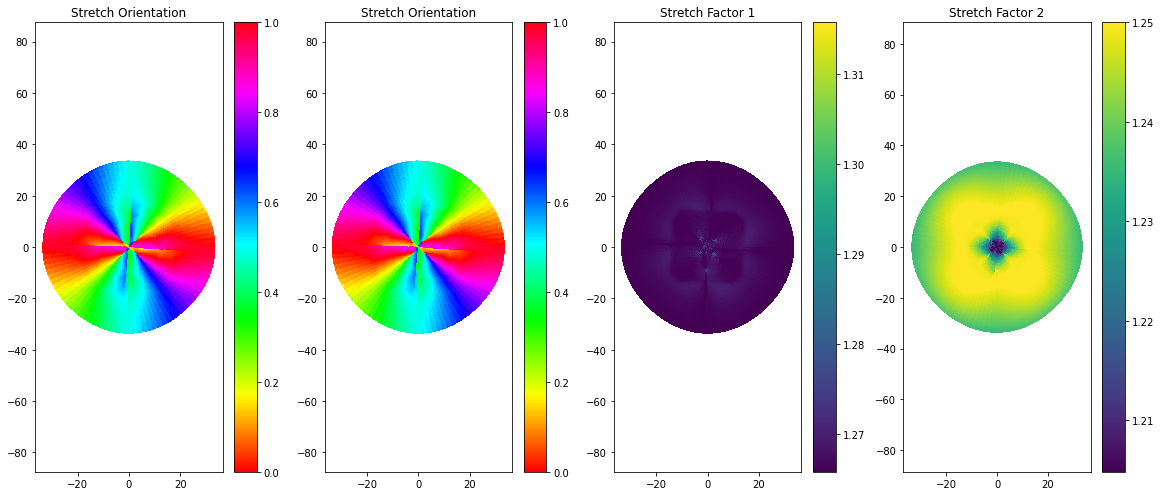

In [8]:
visualization.visualize_both(lg)

In [9]:
lg.energy()


1.0088098076933073e-23

In [10]:
rparam = parametrization.RegularizedGenericParametrizer(lg)
rparam.useBarrier = True

In [11]:
PET = parametrization.RegularizedGenericParametrizer.EnergyType
list(map(rparam.energy, [PET.Fitting, PET.StretchRegularization, PET.PhiRegularization, PET.DiffRegularization]))

[1.0086255070219387e-23,
 0.05218449663737371,
 3.8898169560077,
 28686.296533341014]

In [12]:
rparam.stretchRegP, rparam.phiRegP

(2.0, 2.0)

In [13]:
def optimize_rparam(param, alphaRegW, phiRegW, diffRegW = 0):
    param.stretchRegW = alphaRegW
    # param.alphaRegW = alphaRegW    
    param.phiRegW = phiRegW
    param.diffRegW = diffRegW
    opts = NewtonOptimizerOptions()
    opts.useIdentityMetric = True
    opts.beta = 1e-4
    opts.niter = 2000
    opts.gradTol = 1e-9
    opts.factorizer = opts.factorizer.CatamariNesdis
    benchmark.reset()
    cr = parametrization.regularized_parametrization_newton(param, [param.uOffset(), param.vOffset(), param.phiOffset()], opts)
    benchmark.report()
    return cr

In [ ]:
# with suppress_stdout(): report = optimize_rparam(rparam, 2e-3, 2e-3, 0)
# with suppress_stdout(): report = optimize_rparam(rparam, 1e-4, 3e-5, 0)
# # with suppress_stdout(): report = optimize_rparam(rparam, 1e-5, 1, 0)

with suppress_stdout(): report = optimize_rparam(rparam, 2e-3, 2e-3, 0)
with suppress_stdout(): report = optimize_rparam(rparam, 1e-4, 1e-5, 0)
with suppress_stdout(): report = optimize_rparam(rparam, 1e-5, 1e-6, 0)


In [26]:
PET = parametrization.RegularizedGenericParametrizer.EnergyType
list(map(rparam.energy, [PET.Fitting, PET.StretchRegularization, PET.PhiRegularization]))

[3.307872308475712e-31, 4.370230605343922e-28, 1.7274575140626318e-05]

In [54]:
report.success


True

In [55]:
rparam.alphaMin, rparam.alphaMax, rparam.getAlphas().min(), rparam.getAlphas().max()

(1.2658227848101264,
 1.3157894736842106,
 1.2658227848101264,
 1.2658227848101264)

In [57]:
rparam.betaMin, rparam.betaMax, rparam.getBetas().min(), rparam.getBetas().max()

(1.2048192771084338, 1.25, 1.2387296496554732, 1.2387296496554745)

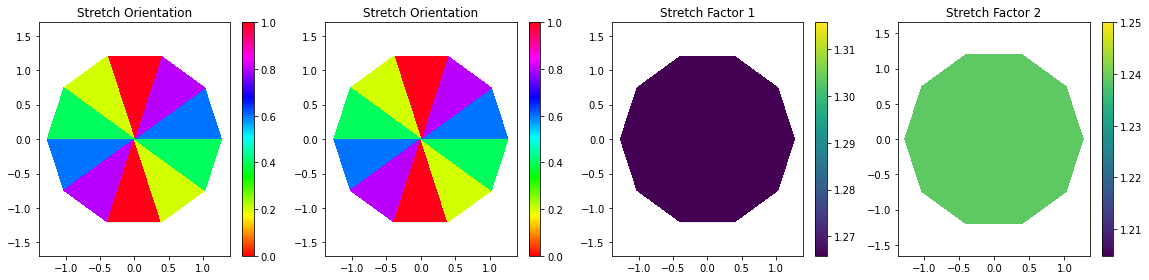

In [60]:
visualization.visualize_both(lg, height = 4)

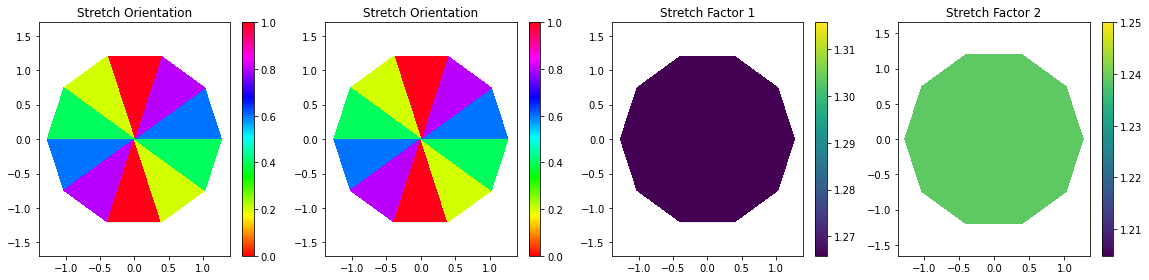

In [61]:
visualization.visualize_both(rparam, height = 4)

In [ ]:
importlib.reload(visualization)
visualization.visualizeChannelOrientation(rparam, quiver=visualization.QuiverVisualization.PER_VTX, orientationHue=False)


In [ ]:
# visualization.singularValueHistogramBoth(rparam)

In [ ]:
widths = wwf.wallWidthForCanonicalWidth(wwf.canonicalWallWidthForStretchFactor(rparam.getAlphas()), 10)
(np.min(widths), np.max(widths))

## Upsampling and channel generation

In [ ]:
nsubdiv=4
upsampledMesh, upsampledAngles, upsampledStretches = rparam.upsampledVertexLeftStretchAnglesAndMagnitudes(nsubdiv)
(sdfVertices, sdfTris, sdf) = wall_generation.evaluate_stripe_field(upsampledMesh.vertices(), upsampledMesh.triangles(), upsampledAngles,
                                                                    wwf.canonicalWallWidthForStretchFactor(upsampledStretches), frequency=100)
pickle.dump((sdfVertices, sdfTris, sdf), open('stripe_sdf_ns4_f100.pkl', 'wb'))

In [ ]:
rparam.getBetas()

In [ ]:
upsampledAngles.shape, upsampledStretches.shape

In [ ]:
upsampledMesh.vertices().shape

In [ ]:
import pickle, mesh, wall_generation, visualization, numpy as np
(sdfVertices, sdfTris, sdf) = pickle.load(open('stripe_sdf_ns4_f100.pkl', 'rb'))

In [ ]:
visualization.scalarFieldPlotFast(sdfVertices, sdfTris, sdf, height=12)

In [ ]:
pts, edges = wall_generation.extract_contours(sdfVertices, sdfTris, sdf,
                                              targetEdgeSpacing=0.01,
                                              minContourLen=0.075)

In [ ]:
visualization.plot_line_segments(pts, edges, width=20, height=16)


## Meshing and inflation simulation

In [ ]:
m, fuseMarkers, fuseSegments = wall_generation.triangulate_channel_walls(pts[:,0:2], edges, 0.0002)
visualization.plot_2d_mesh(m, pointList=np.where(np.array(fuseMarkers) == 1)[0], width=20, height=18)

In [ ]:
import inflation
isheet = inflation.InflatableSheet(m, np.array(fuseMarkers) != 0)

In [ ]:
from mesh_utilities import SurfaceSampler, tubeRemesh


In [ ]:
paramSampler = SurfaceSampler(np.pad(rparam.uv(), [(0, 0), (0, 1)], 'constant'), input_mesh.triangles())
liftedSheetPositions = paramSampler.sample(m.vertices(), input_mesh.vertices())

In [ ]:
isheet.setUninflatedDeformation(liftedSheetPositions.transpose())

In [ ]:
import py_newton_optimizer
niter = 2000
iterations_per_output = 10
opts = py_newton_optimizer.NewtonOptimizerOptions()
opts.useIdentityMetric = True
opts.beta = 1e-4
opts.gradTol = 1e-10
opts.niter = iterations_per_output

In [ ]:
# Are the flat region causing a problem? They might not actually control the metric...
# Try replacing them with single wall...
# Analyze the actual stretching factor (much easier to do with skeleton walls)

In [ ]:
from tri_mesh_viewer import TriMeshViewer
viewer = TriMeshViewer(isheet.visualizationMesh(), width=768, height=640)
viewer.showWireframe()
viewer.show()

In [ ]:
isheet.setUseTensionFieldEnergy(True)

In [ ]:
mkdir lilium_inflate_freq100

In [ ]:
fixedVars, hessianShift = [], 1e-6


In [ ]:
import time
isheet.pressure = 35
benchmark.reset()
for step in range(int(niter / iterations_per_output)):
    cr = inflation.inflation_newton(isheet, fixedVars, opts, hessianShift = hessianShift)
    if cr.numIters() < iterations_per_output: break
    isheet.writeDebugMesh('lilium_inflate_freq100/inflation_tf_lifted_step_{}.msh'.format(step))
    viewer.update(False, isheet.visualizationMesh())
    time.sleep(0.05) # Allow some mesh synchronization time for pythreejs
benchmark.report()

In [ ]:
isheet.tensionStateHistogram()